# 03. 米国債 月次リバランス戦略バックテスト（2006/04〜2026/03）

このノートブックでは、宮崎・阿部・島田（2021）の「キャリーロールダウン + 因子分析の誤差項」という発想を参考にしつつ、論文の完全再現ではなく、長期で使いやすい米国債セクター戦略を検証する。

主な設計は以下の通り。

- 対象: 米国債コンスタント・マチュリティー利回りから作る13セクター（1Y, 2Y, ..., 30Y）
- 期間: 2006年4月末のシグナルから2026年3月末までの月次リターン
- リバランス: 月次
- 推定: 過去24か月の利回りだけでローリング因子分析を行う
- 制約: ロングオンリー、完全投資、等加重ベンチマークへのデュレーション一致
- 比較: 単純CA&RD、因子残差平均回帰、ウエイト上限、売買平滑化を比較する

実装上の重要点として、シグナル計算は時点 $t$ までの情報だけを使い、実現リターンだけに翌月末 $t+1$ の利回りを使う。

## セットアップ

必要なライブラリを読み込み、分析に使う定数を定義する。データ取得にはFRED APIを使う。ローリング因子モデルの推定開始前に24か月分の履歴が必要なので、データは2004年4月から取得する。

In [1]:
import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from fredapi import Fred
from scipy.interpolate import CubicSpline
from scipy.optimize import linprog
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401

from performance import calc_information_ratio, calc_tracking_error, calc_win_rate

# ---- パス ----
DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)
YIELD_PATH = DATA_DIR / "us_treasury_yields_2004_2026.xlsx"
RESULT_PATH = DATA_DIR / "backtest_2006_2026_monthly_results.xlsx"

# ---- 期間 ----
DATA_START = "2004-01-01"
DATA_MONTHLY_START = "2004-04-30"
DATA_END = "2026-03-31"
BACKTEST_START = pd.Timestamp("2006-04-30")
BACKTEST_LAST_SIGNAL = pd.Timestamp("2026-02-28")

# ---- セクター ----
CURVE_NODES = np.array([0.5, 1, 2, 3, 5, 7, 10, 20, 30], dtype=float)
MATURITIES = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30], dtype=float)
SECTOR_NAMES = ["1Y", "2Y", "3Y", "4Y", "5Y", "6Y", "7Y", "8Y", "9Y", "10Y", "15Y", "20Y", "30Y"]
N_SECTORS = len(MATURITIES)

SERIES_MAP = {
    0.5: "DGS6MO",
    1: "DGS1",
    2: "DGS2",
    3: "DGS3",
    5: "DGS5",
    7: "DGS7",
    10: "DGS10",
    20: "DGS20",
    30: "DGS30",
}

# ---- 戦略パラメータ（事前固定） ----
LOOKBACK_MONTHS = 24
RESIDUAL_HALF_LIFE_MONTHS = 6
GAMMA_MONTHLY = 1 - 0.5 ** (1 / RESIDUAL_HALF_LIFE_MONTHS)
MAX_WEIGHT = 0.35
MAX_SECTOR_TRADE = 0.15
TRANSACTION_COST_BPS = 2.0  # 片道100%売買あたり2bp

print(f"月次残差修正率 gamma: {GAMMA_MONTHLY:.4f}")

月次残差修正率 gamma: 0.1091


## データ取得と保存

FREDの日次CMT系列から月末値を作り、6か月・1年・2年・3年・5年・7年・10年・20年・30年のノードを使って13セクターへスプライン補間する。1年セクターの1か月ロールダウンでは1年未満の利回りが必要になるため、6か月金利もカーブのノードに含める。

In [2]:
def fetch_fred_series_with_retry(fred, series_id, start, end, max_attempts=5, sleep_seconds=2.0):
    import time

    last_error = None
    for attempt in range(1, max_attempts + 1):
        try:
            return fred.get_series(series_id, observation_start=start, observation_end=end)
        except Exception as exc:
            last_error = exc
            if attempt == max_attempts:
                raise
            wait = sleep_seconds * attempt
            print(f"{series_id}: FRED取得失敗 ({exc}); {wait:.1f}秒待って再試行します")
            time.sleep(wait)

    raise last_error


def load_or_fetch_yields(force_refresh: bool = False):
    if YIELD_PATH.exists() and not force_refresh:
        yields = pd.read_excel(YIELD_PATH, sheet_name="yields", index_col=0, parse_dates=True)
        nodes = pd.read_excel(YIELD_PATH, sheet_name="source_nodes", index_col=0, parse_dates=True)
        return yields, nodes

    load_dotenv(dotenv_path="../.private/.env")
    fred_api_key = os.environ["FRED_API_KEY"]
    fred = Fred(api_key=fred_api_key)

    raw = {}
    for maturity, series_id in SERIES_MAP.items():
        raw[maturity] = fetch_fred_series_with_retry(
            fred,
            series_id,
            start=DATA_START,
            end=DATA_END,
        )

    daily = pd.DataFrame(raw).sort_index().ffill()
    nodes = daily.resample("ME").last().loc[DATA_MONTHLY_START:DATA_END]
    nodes.columns = [f"{m:g}Y" for m in CURVE_NODES]

    interpolated = []
    for _, row in nodes.iterrows():
        cs = CubicSpline(CURVE_NODES, row.values.astype(float), extrapolate=True)
        interpolated.append(cs(MATURITIES))

    yields = pd.DataFrame(interpolated, index=nodes.index, columns=SECTOR_NAMES)

    with pd.ExcelWriter(YIELD_PATH) as writer:
        yields.to_excel(writer, sheet_name="yields")
        nodes.to_excel(writer, sheet_name="source_nodes")

    return yields, nodes

# force_refresh=True にするとFREDから再取得する。
yields, curve_nodes = load_or_fetch_yields(force_refresh=False)

print(f"利回りデータ: {yields.index[0].date()}〜{yields.index[-1].date()}, shape={yields.shape}")
print(f"欠損セル数: {int(yields.isna().sum().sum())}")
display(yields.head())
display(yields.tail())

利回りデータ: 2004-04-30〜2026-03-31, shape=(264, 13)
欠損セル数: 0


,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,15Y,20Y,30Y
2004-04-30,1.55,2.31,2.86,3.286065,3.63,3.899695,4.11,4.276746,4.412732,4.53,5.005480,5.31,5.39
2004-05-31,1.83,2.54,3.10,3.508535,3.81,4.057056,4.26,4.420717,4.549795,4.66,5.106920,5.39,5.42
2004-06-30,2.09,2.70,3.16,3.521538,3.81,4.047297,4.24,4.392406,4.515043,4.62,5.049335,5.33,5.41
2004-07-31,2.13,2.68,3.09,3.427687,3.71,3.942585,4.13,4.277863,4.397109,4.50,4.937441,5.24,5.31
2004-08-31,1.99,2.41,2.75,3.053891,3.33,3.566822,3.76,3.909852,4.028262,4.13,4.586864,4.93,5.01


,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,15Y,20Y,30Y
2025-11-30,3.61,3.47,3.49,3.533994,3.59,3.678654,3.78,3.869892,3.948011,4.02,4.357443,4.62,4.67
2025-12-31,3.48,3.47,3.55,3.636947,3.73,3.835331,3.94,4.030259,4.108229,4.18,4.520689,4.79,4.84
2026-01-31,3.48,3.52,3.60,3.686741,3.79,3.901876,4.01,4.103958,4.185638,4.26,4.586606,4.82,4.87
2026-02-28,3.48,3.38,3.39,3.436483,3.51,3.611481,3.72,3.814579,3.895886,3.97,4.310083,4.57,4.64
2026-03-31,3.68,3.79,3.81,3.843112,3.92,4.016276,4.11,4.184932,4.245194,4.30,4.602777,4.88,4.88


## 月次リターンの近似

各セクターは、月末時点でその年限のパー債を保有し、翌月末まで保有してから再評価する合成ポートフォリオとして扱う。半期クーポンの実支払い日を細かく追うのではなく、ダーティ価格の現在価値として評価することで、月中の経過利息を価格に含める。

この設計により、シグナルも実現リターンも1か月ホライズンで揃える。

In [3]:
def year_fraction(start, end):
    return (end - start).days / 365.25


def cashflow_times(original_maturity, elapsed=0.0, freq=2):
    payment_times = np.arange(1 / freq, original_maturity + 1e-9, 1 / freq) - elapsed
    return payment_times[payment_times > 1e-10]


def price_bond_elapsed(y_coupon, y_discount, original_maturity, elapsed=0.0, freq=2):
    """時点0で残存 original_maturity のパー債を elapsed 年後に評価するダーティ価格。"""
    times = cashflow_times(original_maturity, elapsed=elapsed, freq=freq)
    if len(times) == 0:
        return 100.0

    coupon = y_coupon * 100 / freq
    cashflows = np.full(len(times), coupon)
    cashflows[-1] += 100
    discount = (1 + y_discount / freq) ** (freq * times)
    return float(np.sum(cashflows / discount))


def modified_duration(y, maturity, freq=2, dy=1e-4):
    p0 = price_bond_elapsed(y, y, maturity, elapsed=0.0, freq=freq)
    p_up = price_bond_elapsed(y, y + dy, maturity, elapsed=0.0, freq=freq)
    p_down = price_bond_elapsed(y, y - dy, maturity, elapsed=0.0, freq=freq)
    return -(p_up - p_down) / (2 * dy) / p0


def convexity(y, maturity, freq=2, dy=1e-4):
    p0 = price_bond_elapsed(y, y, maturity, elapsed=0.0, freq=freq)
    p_up = price_bond_elapsed(y, y + dy, maturity, elapsed=0.0, freq=freq)
    p_down = price_bond_elapsed(y, y - dy, maturity, elapsed=0.0, freq=freq)
    return (p_up - 2 * p0 + p_down) / (dy**2) / p0


# パー価格の確認
for maturity in [1, 5, 10, 30]:
    print(f"{maturity:>2}Y par price @ 3%: {price_bond_elapsed(0.03, 0.03, maturity):.6f}")

 1Y par price @ 3%: 100.000000
 5Y par price @ 3%: 100.000000
10Y par price @ 3%: 100.000000
30Y par price @ 3%: 100.000000


## 因子モデルとシナリオリターン

因子モデルは時点 $t$ より前の24か月だけで推定する。推定したローディングを固定して、時点 $t$ のカーブからクロスセクションOLSでモデル利回りと誤差項を推定する。

戦略シグナルは以下の3種類を使う。

- `CARD_raw`: 現在のイールドカーブが1か月後も同じ形で残ると仮定した月次CA&RD
- `REV_raw`: 3因子モデルの誤差項が6か月半減ペースで平均回帰すると仮定したシナリオ
- `REV_cap35`: `REV_raw` に各セクター35%上限を加えた版
- `REV_smooth15`: `REV_cap35` に、各月の1セクターあたり売買変化15%上限を加えた実務寄り版

In [4]:
def fit_factor_model(history_pct):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(history_pct.values.astype(float))
    fa = FactorAnalysis(n_components=3, random_state=42, max_iter=2000)
    fa.fit(scaled)
    loadings = fa.components_.T
    return scaler, loadings


def estimate_model_yield(y_pct, scaler, loadings):
    y_scaled = scaler.transform(y_pct.reshape(1, -1)).ravel()
    factor_values = np.linalg.lstsq(loadings, y_scaled, rcond=None)[0]
    model_scaled = loadings @ factor_values
    model_pct = model_scaled * scaler.scale_ + scaler.mean_
    residual_pct = y_pct - model_pct
    return model_pct, residual_pct, factor_values


def forecast_returns(row_sector_pct, row_node_pct, mode, horizon, model_pct=None, residual_pct=None, gamma=0.0):
    y_current = row_sector_pct.astype(float) / 100
    actual_curve = CubicSpline(CURVE_NODES, row_node_pct.astype(float) / 100, extrapolate=True)

    if model_pct is not None:
        model_curve = CubicSpline(MATURITIES, model_pct.astype(float) / 100, extrapolate=True)

    forecasts = []
    for k, maturity in enumerate(MATURITIES):
        y_i = y_current[k]
        if mode == "card":
            y_horizon = float(actual_curve(maturity - horizon))
        elif mode == "model":
            model_i = model_pct[k] / 100
            y_horizon = y_i + (float(model_curve(maturity - horizon)) - model_i)
        elif mode == "reversion":
            model_i = model_pct[k] / 100
            eps_i = residual_pct[k] / 100
            y_horizon = y_i + (float(model_curve(maturity - horizon)) - model_i - gamma * eps_i)
        else:
            raise ValueError(f"unknown mode: {mode}")

        p0 = price_bond_elapsed(y_i, y_i, maturity, elapsed=0.0)
        p1 = price_bond_elapsed(y_i, y_horizon, maturity, elapsed=horizon)
        forecasts.append(p1 / p0 - 1)

    return np.array(forecasts)


def realized_sector_returns(row_sector_pct, next_node_pct, horizon):
    y_current = row_sector_pct.astype(float) / 100
    next_curve = CubicSpline(CURVE_NODES, next_node_pct.astype(float) / 100, extrapolate=True)

    returns = []
    for k, maturity in enumerate(MATURITIES):
        y_i = y_current[k]
        y_next = float(next_curve(maturity - horizon))
        p0 = price_bond_elapsed(y_i, y_i, maturity, elapsed=0.0)
        p1 = price_bond_elapsed(y_i, y_next, maturity, elapsed=horizon)
        returns.append(p1 / p0 - 1)

    return np.array(returns)

## 最適化と評価指標

最適化は線形計画で行う。全戦略に完全投資・ロングオンリー・等加重ベンチマークへのデュレーション一致を課す。売買平滑化版では、前月ウエイトから各セクター15%を超えて動かさない制約も加える。

In [5]:
def optimize_weights(signal, durations, target_duration, max_weight=1.0, prev_weight=None, max_sector_trade=None):
    bounds = []
    for i in range(N_SECTORS):
        lo, hi = 0.0, max_weight
        if prev_weight is not None and max_sector_trade is not None:
            lo = max(lo, prev_weight[i] - max_sector_trade)
            hi = min(hi, prev_weight[i] + max_sector_trade)
        bounds.append((lo, hi))

    a_eq = np.vstack([np.ones(N_SECTORS), durations])
    b_eq = np.array([1.0, target_duration])

    res = linprog(-signal, A_eq=a_eq, b_eq=b_eq, bounds=bounds, method="highs")
    if not res.success and prev_weight is not None:
        # 売買平滑化で稀に実行不能になる場合は、平滑化だけ外して解く。
        fallback_bounds = [(0.0, max_weight)] * N_SECTORS
        res = linprog(-signal, A_eq=a_eq, b_eq=b_eq, bounds=fallback_bounds, method="highs")

    if not res.success:
        raise RuntimeError(res.message)
    return res.x


def one_way_turnover(new_weight, old_weight):
    return 0.5 * np.abs(new_weight - old_weight).sum()


def apply_transaction_cost(gross_return, turnover, tc_bps=TRANSACTION_COST_BPS):
    return gross_return - turnover * tc_bps / 10000


def annualized_return(ret):
    ret = pd.Series(ret).dropna()
    return (1 + ret).prod() ** (12 / len(ret)) - 1


def annualized_vol(ret):
    return pd.Series(ret).dropna().std(ddof=1) * np.sqrt(12)


def max_drawdown(ret):
    wealth = (1 + pd.Series(ret).dropna()).cumprod()
    return (wealth / wealth.cummax() - 1).min()


def summarize_performance(returns, benchmark_col="BM_equal"):
    rows = []
    benchmark = returns[benchmark_col]
    for col in returns.columns:
        r = returns[col].dropna()
        row = {
            "年率リターン(幾何)": annualized_return(r),
            "年率ボラ": annualized_vol(r),
            "最大DD": max_drawdown(r),
        }
        if col != benchmark_col:
            alpha = r - benchmark.reindex(r.index)
            te = calc_tracking_error(alpha)
            row.update({
                "年率超過(算術)": alpha.mean() * 12,
                "TE": te,
                "IR": np.nan if te == 0 else alpha.mean() * 12 / te,
                "勝率": calc_win_rate(alpha),
            })
        rows.append(pd.Series(row, name=col))
    return pd.DataFrame(rows)

## バックテスト実行

2006年4月末に最初のシグナルを計算し、翌月末の2006年5月リターンから記録する。最後は2026年2月末シグナルで2026年3月末まで保有する。

In [6]:
strategy_names = [
    "BM_equal",
    "CARD_raw",
    "REV_raw",
    "REV_cap35",
    "REV_smooth15",
]

returns_gross = {name: [] for name in strategy_names}
returns_net = {name: [] for name in strategy_names}
weights = {name: [] for name in strategy_names if name != "BM_equal"}
turnovers = {name: [] for name in strategy_names if name != "BM_equal"}
forecast_store = []
residual_store = []
rebalance_dates = []

prev_weights = {name: np.ones(N_SECTORS) / N_SECTORS for name in weights}
all_dates = yields.index

for dt in all_dates[:-1]:
    if dt < BACKTEST_START or dt > BACKTEST_LAST_SIGNAL:
        continue

    loc = all_dates.get_loc(dt)
    history = yields.iloc[loc - LOOKBACK_MONTHS:loc]
    if len(history) < LOOKBACK_MONTHS:
        continue

    next_dt = all_dates[loc + 1]
    horizon = year_fraction(dt, next_dt)

    row_sector = yields.loc[dt].values.astype(float)
    row_nodes = curve_nodes.loc[dt].values.astype(float)
    next_nodes = curve_nodes.loc[next_dt].values.astype(float)

    scaler, loadings = fit_factor_model(history)
    model_pct, residual_pct, factor_values = estimate_model_yield(row_sector, scaler, loadings)

    durations = np.array([modified_duration(row_sector[k] / 100, maturity) for k, maturity in enumerate(MATURITIES)])
    benchmark_weight = np.ones(N_SECTORS) / N_SECTORS
    benchmark_duration = benchmark_weight @ durations

    realized = realized_sector_returns(row_sector, next_nodes, horizon)
    card_signal = forecast_returns(row_sector, row_nodes, mode="card", horizon=horizon)
    reversion_signal = forecast_returns(
        row_sector,
        row_nodes,
        mode="reversion",
        horizon=horizon,
        model_pct=model_pct,
        residual_pct=residual_pct,
        gamma=GAMMA_MONTHLY,
    )

    signal_map = {
        "CARD_raw": (card_signal, 1.0, None),
        "REV_raw": (reversion_signal, 1.0, None),
        "REV_cap35": (reversion_signal, MAX_WEIGHT, None),
        "REV_smooth15": (reversion_signal, MAX_WEIGHT, MAX_SECTOR_TRADE),
    }

    rebalance_dates.append(next_dt)
    bm_return = benchmark_weight @ realized
    returns_gross["BM_equal"].append(bm_return)
    returns_net["BM_equal"].append(bm_return)

    for name, (signal, max_weight, max_trade) in signal_map.items():
        weight = optimize_weights(
            signal=signal,
            durations=durations,
            target_duration=benchmark_duration,
            max_weight=max_weight,
            prev_weight=prev_weights[name],
            max_sector_trade=max_trade,
        )
        turnover = one_way_turnover(weight, prev_weights[name])
        gross_return = weight @ realized
        net_return = apply_transaction_cost(gross_return, turnover)

        weights[name].append(weight)
        turnovers[name].append(turnover)
        returns_gross[name].append(gross_return)
        returns_net[name].append(net_return)
        prev_weights[name] = weight

    forecast_store.append(pd.Series(reversion_signal, index=SECTOR_NAMES, name=dt))
    residual_store.append(pd.Series(residual_pct, index=SECTOR_NAMES, name=dt))

returns_gross = pd.DataFrame(returns_gross, index=rebalance_dates)
returns_net = pd.DataFrame(returns_net, index=rebalance_dates)
weight_dfs = {
    name: pd.DataFrame(values, index=[d - pd.offsets.MonthEnd(1) for d in rebalance_dates], columns=SECTOR_NAMES)
    for name, values in weights.items()
}
turnover_df = pd.DataFrame(turnovers, index=rebalance_dates)
forecast_df = pd.DataFrame(forecast_store)
residual_df = pd.DataFrame(residual_store)

print(f"バックテスト月数: {len(returns_gross)}")
print(f"リターン期間: {returns_gross.index[0].date()}〜{returns_gross.index[-1].date()}")
display(returns_gross.head())

バックテスト月数: 239
リターン期間: 2006-05-31〜2026-03-31


,BM_equal,CARD_raw,REV_raw,REV_cap35,REV_smooth15
2006-05-31,-0.000027,0.001631,0.000966,0.000895,0.000368
2006-06-30,0.002919,0.004395,0.003829,0.003894,0.003545
2006-07-31,0.014372,0.013442,0.014588,0.013939,0.014248
2006-08-31,0.018614,0.019746,0.020268,0.019973,0.019997
2006-09-30,0.010691,0.011072,0.011214,0.010995,0.010887


## パフォーマンス比較

総合評価は、取引コスト控除後のネットリターンを主に見る。取引コストは片道100%売買あたり2bpとした。米国債現物・先物・ETFなど実際の実装手段によってコストは異なるため、ここでは保守的な感度確認のための値として置いている。

In [7]:
def format_performance_table(summary):
    """IR以外の比率列だけ%表示へ変換する。"""
    out = summary.copy()
    for col in out.columns:
        if col != "IR":
            out[col] = out[col] * 100
    return out.round(2)


summary_gross = summarize_performance(returns_gross)
summary_net = summarize_performance(returns_net)

avg_turnover = turnover_df.mean().rename("平均片道ターンオーバー")
summary_net = summary_net.join(avg_turnover, how="left")
summary_gross = summary_gross.join(avg_turnover, how="left")

print("=== Gross performance ===")
display(format_performance_table(summary_gross))
print("=== Net performance after transaction cost ===")
display(format_performance_table(summary_net))

recommended = "REV_cap35"
print(f"推奨候補: {recommended}")

=== Gross performance ===


,年率リターン(幾何),年率ボラ,最大DD,年率超過(算術),TE,IR,勝率,平均片道ターンオーバー
BM_equal,3.33,5.92,-21.23,NaN,NaN,NaN,NaN,NaN
CARD_raw,3.77,6.09,-20.17,0.44,0.94,0.46,57.74,29.42
REV_raw,4.09,6.08,-19.60,0.74,0.88,0.84,60.67,46.81
REV_cap35,3.95,6.08,-20.35,0.61,0.74,0.82,59.83,38.20
REV_smooth15,3.81,6.04,-20.70,0.47,0.70,0.66,58.58,25.76


=== Net performance after transaction cost ===


,年率リターン(幾何),年率ボラ,最大DD,年率超過(算術),TE,IR,勝率,平均片道ターンオーバー
BM_equal,3.33,5.92,-21.23,NaN,NaN,NaN,NaN,NaN
CARD_raw,3.70,6.10,-20.30,0.37,0.94,0.39,56.90,29.42
REV_raw,3.97,6.08,-19.84,0.63,0.88,0.71,59.41,46.81
REV_cap35,3.85,6.08,-20.54,0.51,0.74,0.70,57.32,38.20
REV_smooth15,3.74,6.04,-20.84,0.41,0.70,0.58,56.07,25.76


推奨候補: REV_cap35


## 累積リターンと超過リターン

単純な年率だけでなく、どの時期に差が出ているかを見る。特に2008年、2013年、2020年、2022年のような金利局面で挙動が崩れていないかを確認する。

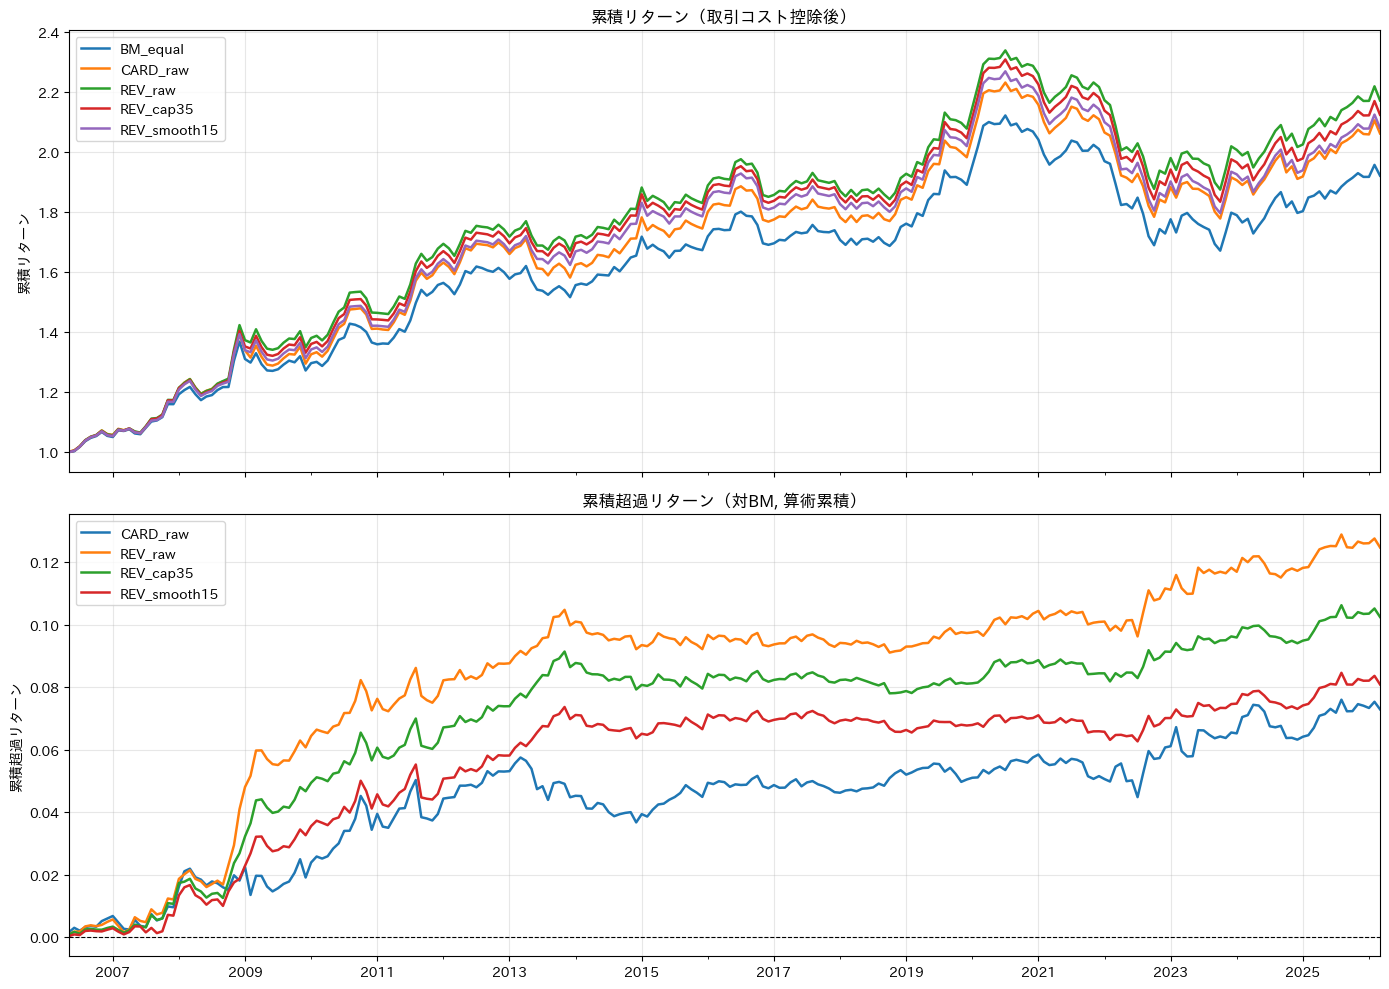

In [8]:
def cumulative_returns(ret_df):
    return (1 + ret_df).cumprod()

cum_net = cumulative_returns(returns_net)
alpha_cum_net = returns_net.sub(returns_net["BM_equal"], axis=0).cumsum()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

cum_net.plot(ax=axes[0], linewidth=1.8)
axes[0].set_title("累積リターン（取引コスト控除後）")
axes[0].set_ylabel("累積リターン")
axes[0].grid(True, alpha=0.3)

alpha_cum_net.drop(columns=["BM_equal"]).plot(ax=axes[1], linewidth=1.8)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("累積超過リターン（対BM, 算術累積）")
axes[1].set_ylabel("累積超過リターン")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## サブ期間分析

長期バックテストは、全期間の平均だけでは判断しにくい。金利上昇・低下・ゼロ金利・インフレ局面をざっくり分けて、戦略の効き方を確認する。

In [9]:
subperiods = {
    "2006-05〜2009-12": ("2006-05-31", "2009-12-31"),
    "2010-01〜2019-12": ("2010-01-31", "2019-12-31"),
    "2020-01〜2021-12": ("2020-01-31", "2021-12-31"),
    "2022-01〜2026-03": ("2022-01-31", "2026-03-31"),
}

sub_rows = []
for label, (start, end) in subperiods.items():
    sub = returns_net.loc[start:end]
    if len(sub) == 0:
        continue
    summary = summarize_performance(sub)
    for strategy in summary.index:
        row = summary.loc[strategy].copy()
        row.name = (label, strategy)
        sub_rows.append(row)

sub_summary = pd.DataFrame(sub_rows)
sub_summary.index = pd.MultiIndex.from_tuples(sub_summary.index, names=["期間", "戦略"])
display(format_performance_table(sub_summary))

年率リターン(幾何)  年率ボラ   最大DD  年率超過(算術)    TE    IR  \
期間              戦略                                                            
2006-05〜2009-12 BM_equal            6.78  7.02  -7.14       NaN   NaN   NaN   
                CARD_raw            7.30  7.48  -7.47      0.52  1.04  0.50   
                REV_raw             8.51  7.56  -5.78      1.66  1.10  1.51   
                REV_cap35           8.11  7.41  -5.92      1.27  0.88  1.44   
                REV_smooth15        7.71  7.30  -6.31      0.89  0.78  1.14   
2010-01〜2019-12 BM_equal            4.04  5.07  -6.41       NaN   NaN   NaN   
                CARD_raw            4.35  5.39  -7.54      0.31  0.89  0.35   
                REV_raw             4.41  5.29  -6.74      0.37  0.78  0.47   
                REV_cap35           4.39  5.26  -6.79      0.34  0.74  0.47   
                REV_smooth15        4.40  5.23  -6.63      0.35  0.74  0.48   
2020-01〜2021-12 BM_equal            3.10  5.48  -7.72       NaN   NaN   NaN   
                CARD_raw            3.15  5.61  -7.58      0.05  0.55  0.10   
                REV_raw             3.28  5.44  -7.46      0.18  0.56  0.32   
                REV_cap35           3.26  5.53  -7.68      0.17  0.50  0.33   
                REV_smooth15        3.00  5.50  -7.74     -0.09  0.46 -0.20   
2022-01〜2026-03 BM_equal           -1.05  6.85 -15.13       NaN   NaN   NaN   
                CARD_raw           -0.53  6.54 -13.87      0.50  1.13  0.44   
                REV_raw            -0.48  6.59 -13.70      0.56  0.99  0.57   
                REV_cap35          -0.63  6.77 -14.20      0.42  0.67  0.63   
                REV_smooth15       -0.70  6.77 -14.45      0.35  0.64  0.55   

                                 勝率  
期間              戦略                   
2006-05〜2009-12 BM_equal        NaN  
                CARD_raw      52.27  
                REV_raw       63.64  
                REV_cap35     61.36  
                REV_smooth15  61.36  
2010-01〜2019-12 BM_equal        NaN  
                CARD_raw      60.00  
                REV_raw       57.50  
                REV_cap35     53.33  
                REV_smooth15  52.50  
2020-01〜2021-12 BM_equal        NaN  
                CARD_raw      54.17  
                REV_raw       66.67  
                REV_cap35     75.00  
                REV_smooth15  62.50  
2022-01〜2026-03 BM_equal        NaN  
                CARD_raw      54.90  
                REV_raw       56.86  
                REV_cap35     54.90  
                REV_smooth15  56.86

## 推奨候補のウエイト推移

`REV_cap35` は、因子残差の平均回帰シグナルを使いつつ、1セクター35%上限で集中を抑えた候補である。以下では、ウエイトとターンオーバーを確認する。

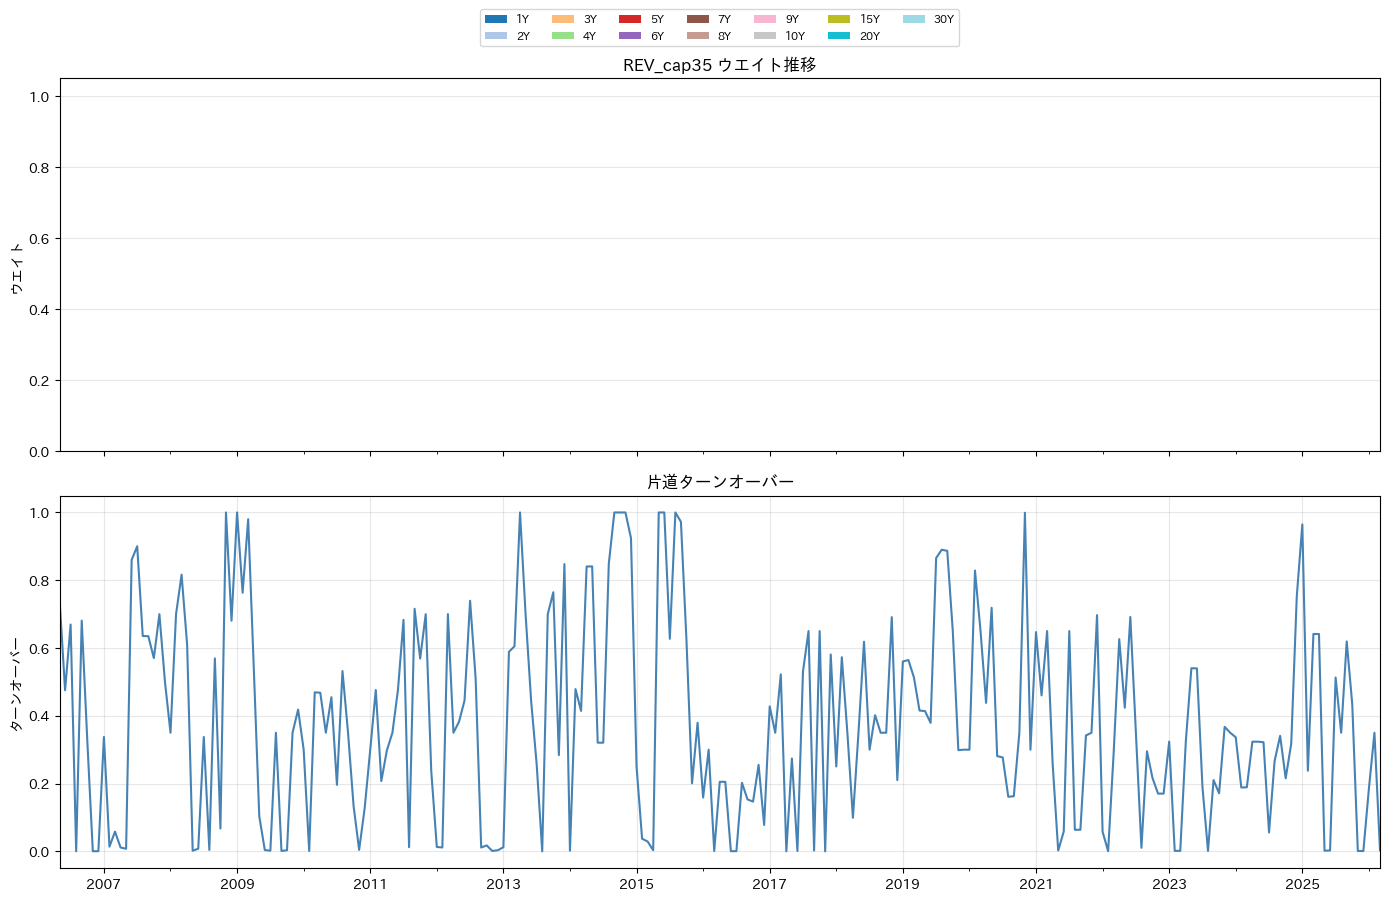

,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,15Y,20Y,30Y
2025-10-31,0.0,0.0,0.0,0.0,0.000000,0.350000,0.35,0.184210,0.0,0.0,0.0,0.115790,0.0
2025-11-30,0.0,0.0,0.0,0.0,0.000000,0.350000,0.35,0.185028,0.0,0.0,0.0,0.114972,0.0
2025-12-31,0.0,0.0,0.0,0.0,0.136362,0.350000,0.35,0.000000,0.0,0.0,0.0,0.163638,0.0
2026-01-31,0.0,0.0,0.0,0.0,0.000000,0.219892,0.35,0.350000,0.0,0.0,0.0,0.080108,0.0
2026-02-28,0.0,0.0,0.0,0.0,0.000000,0.216840,0.35,0.350000,0.0,0.0,0.0,0.083160,0.0


In [10]:
rec_weights = weight_dfs[recommended]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

bottom = np.zeros(len(rec_weights))
colors = plt.cm.tab20(np.linspace(0, 1, N_SECTORS))
for i, col in enumerate(SECTOR_NAMES):
    axes[0].bar(rec_weights.index, rec_weights[col], bottom=bottom, width=25, color=colors[i], label=col)
    bottom += rec_weights[col].values
axes[0].set_title(f"{recommended} ウエイト推移")
axes[0].set_ylabel("ウエイト")
axes[0].set_ylim(0, 1.05)
axes[0].legend(ncol=7, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, 1.20))
axes[0].grid(True, alpha=0.3, axis="y")

turnover_df[recommended].plot(ax=axes[1], color="steelblue", linewidth=1.5)
axes[1].set_title("片道ターンオーバー")
axes[1].set_ylabel("ターンオーバー")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

display(rec_weights.tail())

## 残差シグナルの確認

誤差項は「実際利回り - 3因子モデル利回り」で定義する。プラスならそのセクターの利回りがモデルより高く、価格が相対的に割安と解釈する。

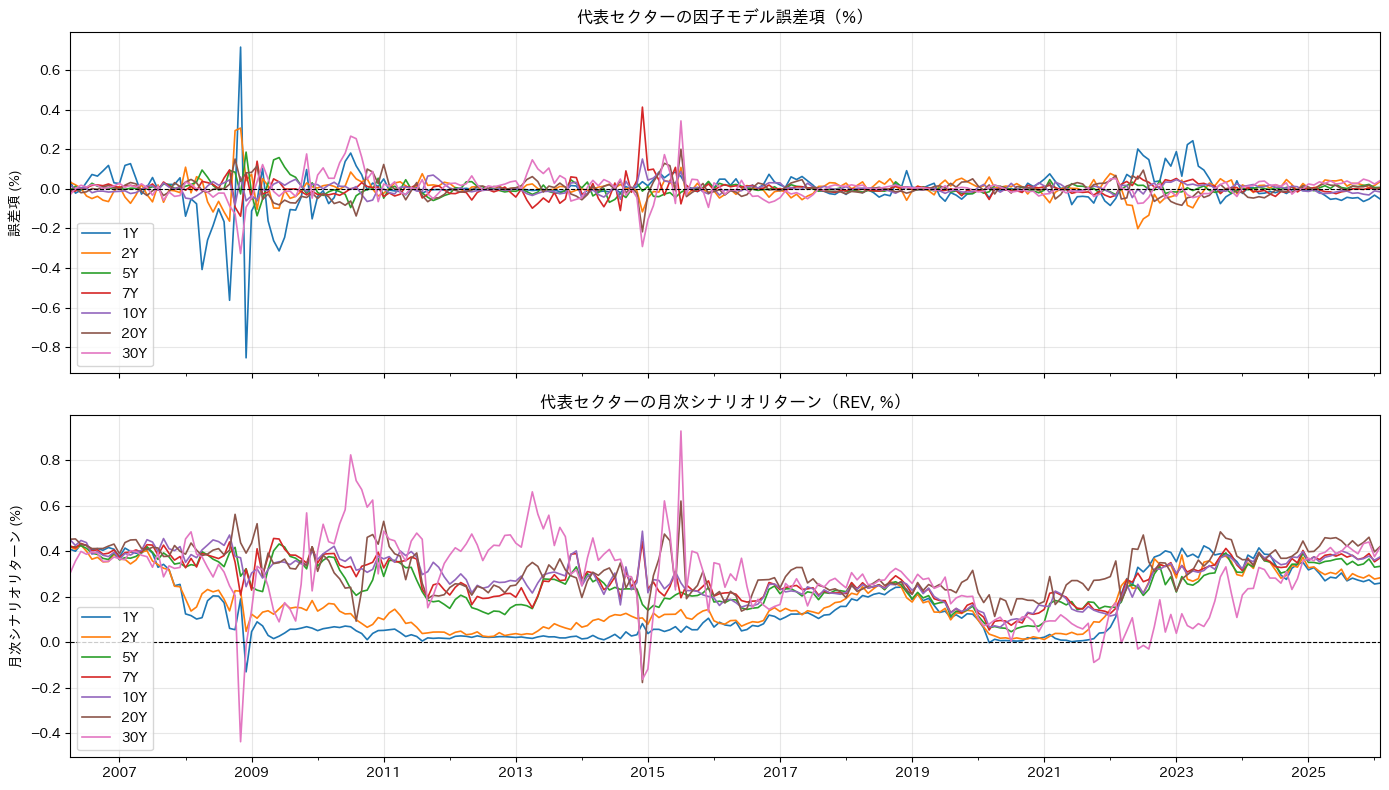

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

residual_df[["1Y", "2Y", "5Y", "7Y", "10Y", "20Y", "30Y"]].plot(ax=axes[0], linewidth=1.2)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("代表セクターの因子モデル誤差項（%）")
axes[0].set_ylabel("誤差項 (%)")
axes[0].grid(True, alpha=0.3)

forecast_df[["1Y", "2Y", "5Y", "7Y", "10Y", "20Y", "30Y"]].mul(100).plot(ax=axes[1], linewidth=1.2)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("代表セクターの月次シナリオリターン（REV, %）")
axes[1].set_ylabel("月次シナリオリターン (%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 結果保存

分析結果をExcelに保存する。ノートブックを再実行すると、同じファイルに上書き保存される。

In [12]:
with pd.ExcelWriter(RESULT_PATH) as writer:
    returns_gross.to_excel(writer, sheet_name="returns_gross")
    returns_net.to_excel(writer, sheet_name="returns_net")
    summary_gross.to_excel(writer, sheet_name="summary_gross")
    summary_net.to_excel(writer, sheet_name="summary_net")
    turnover_df.to_excel(writer, sheet_name="turnover")
    residual_df.to_excel(writer, sheet_name="factor_residuals")
    forecast_df.to_excel(writer, sheet_name="reversion_forecasts")
    for name, wdf in weight_dfs.items():
        sheet = f"weights_{name}"[:31]
        wdf.to_excel(writer, sheet_name=sheet)

print(f"保存完了: {RESULT_PATH}")

保存完了: ../data/backtest_2006_2026_monthly_results.xlsx


## まとめ

このバックテストでは、単純なCA&RDだけでなく、ローリング3因子モデルから得られる相対的な割高・割安の平均回帰を加えた戦略を検証した。

- `REV_raw` はリターンが高くなりやすいが、集中と売買回転が大きい。
- `REV_cap35` は集中を抑えながら、超過リターンとIRのバランスが良い。
- `REV_smooth15` はターンオーバーを抑えたい場合の現実的な代替候補になる。

実運用に近づける次の改善候補は、実際のベンチマークウエイト、先物・ETFでの実装コスト、税・資金調達、レバレッジなし/ありの設計を反映することである。